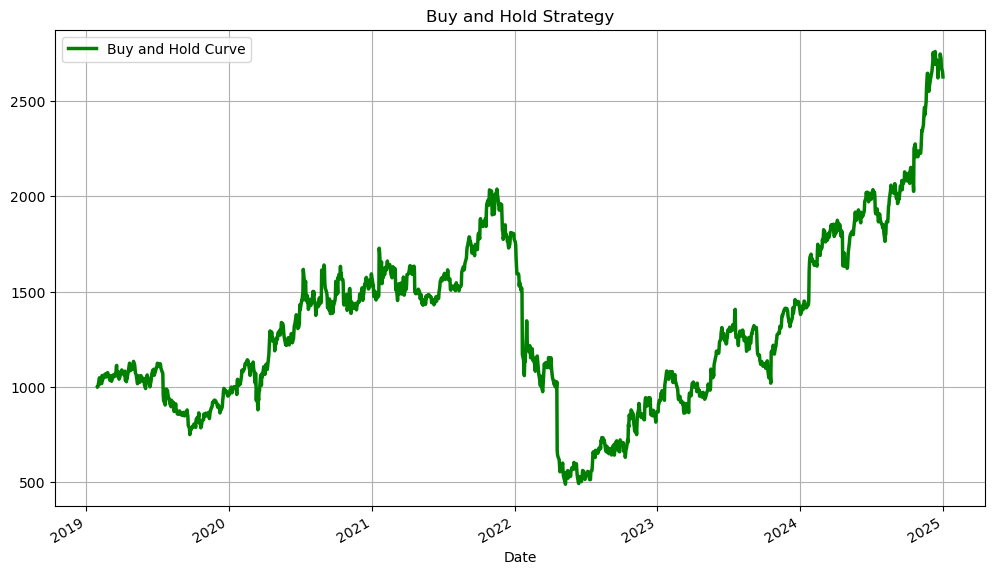

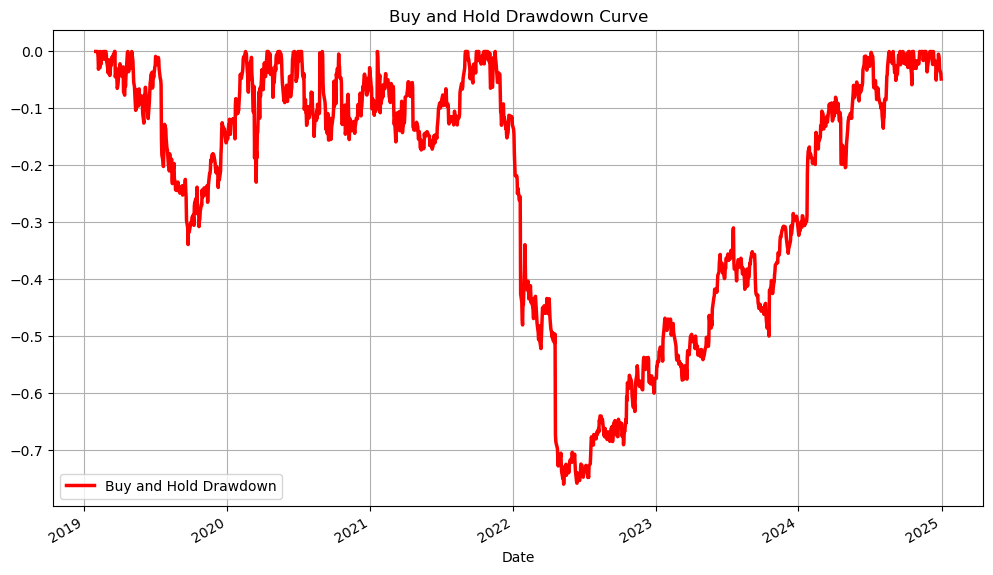

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Fonctions import compute_metrics, drawdown

data_return = pd.read_csv("NFLX_data_return.csv", index_col=0, parse_dates=True).squeeze()
V0 = 1000
equity_bandh = V0 * np.exp(data_return.cumsum())
equity_bandh_filtered = equity_bandh["2019-01-31":]
equity_bandh_filtered = equity_bandh_filtered / equity_bandh_filtered.iloc[0] * V0
data_return_filtered = data_return["2019-01-31":]

plt.figure(figsize=(12,7))
equity_bandh_filtered.plot(color="green", linewidth=2.5, label="Buy and Hold Curve")
plt.title("Buy and Hold Strategy")
plt.grid()
plt.legend()
plt.show()

plt.figure(figsize=(12,7))
drawdown(equity_bandh_filtered).plot(color="red", linewidth=2.5, label="Buy and Hold Drawdown")
plt.title("Buy and Hold Drawdown Curve")
plt.grid()
plt.legend()
plt.show()

pd.DataFrame({
    "Buy and Hold": compute_metrics(data_return_filtered, equity_bandh_filtered, freq="daily")
})

compute_metrics(data_return_filtered, equity_bandh_filtered, freq="daily").to_csv("metrics_bandh.csv")